# **Importing required libraries:**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# **Reading data and displaying first 10 rows,shape and info of it:**

In [55]:
df = pd.read_csv("/content/heart - heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [56]:
df.shape

(918, 12)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [58]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

# **Checking for missing values in the dataset:**

In [59]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


# **Checking for Duplicate Rows in the dataset:**

In [12]:
df.duplicated().sum() # No duplicate found

np.int64(0)

# **Identifying invalid data:**

In [67]:
invalid_ch = (df["Cholesterol"]==0).sum()
invalid_rb = (df["RestingBP"]==0).sum()

print(f"{invalid_ch} rows have Cholesterol as 0")
print(f"{invalid_rb} row have Resting BP as 0")

0 rows have Cholesterol as 0
1 row have Resting BP as 0


# **Replacing invalid data with accurate one:**

In [75]:
chol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
df.loc[df["Cholesterol"] == 0, "Cholesterol"] = chol_mean

rest_bp = df.loc[df["RestingBP"]!=0,"RestingBP"].mean()
df.loc[df["RestingBP"]== 0, "RestingBP"] = rest_bp

df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("After cleaning, the data becomes - ")
print(df['Cholesterol'].describe())
print("-"*30)
print(df["RestingBP"].describe())

After cleaning, the data becomes - 
count    918.000000
mean     244.636253
std       53.318029
min       85.000000
25%      214.000000
50%      244.640000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64
------------------------------
count    918.000000
mean     132.540893
std       17.989932
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


# **Function for plotting the graph:**

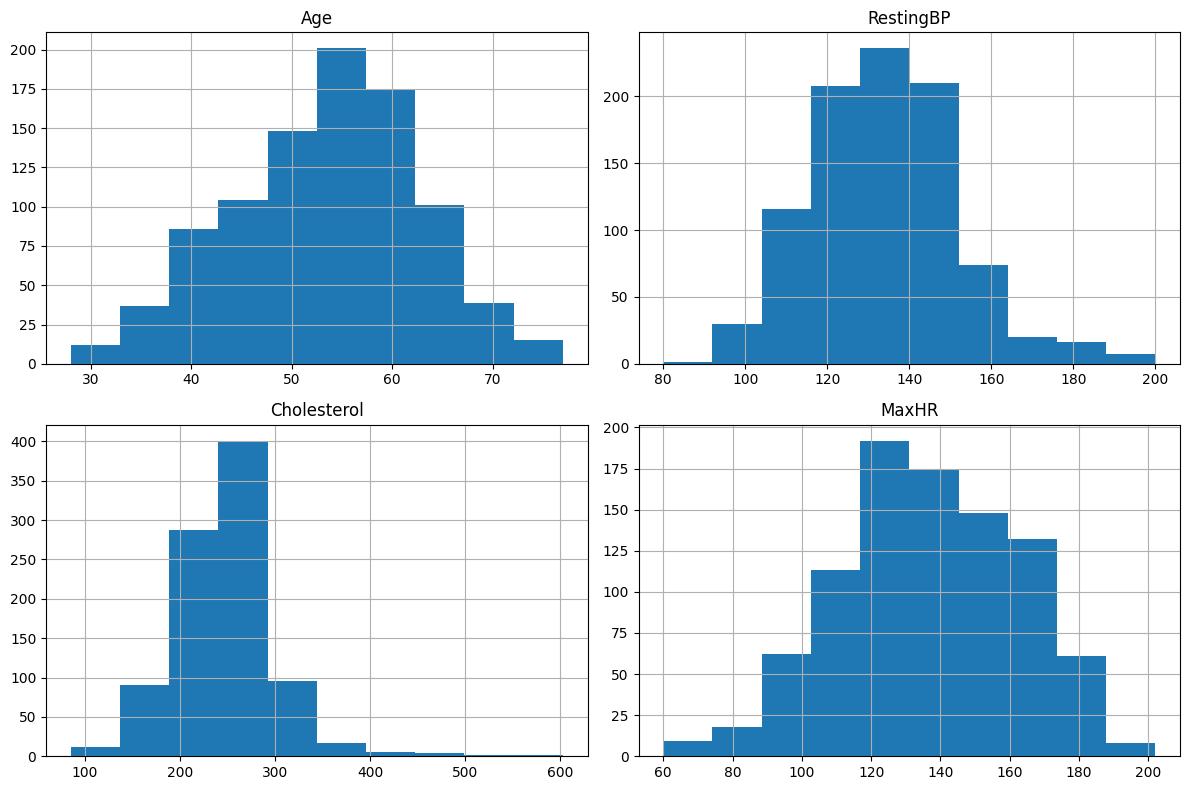

In [78]:
def plot_histogram(position, column):
    plt.subplot(2,2,position)
    plt.hist(df[column])
    plt.title(column)
    plt.grid()

plt.figure(figsize=(12,8))
plot_histogram(1, "Age")
plot_histogram(2, "RestingBP")
plot_histogram(3, "Cholesterol")
plot_histogram(4, "MaxHR")
plt.tight_layout()
plt.show()



# **Identifying Numerical and Categorical columns:**

In [81]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [82]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

print("Numerical Columns:")
print(num_cols)
print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


# **Perfroming one hot ecoding:**

In [85]:
df_encoded = pd.get_dummies(df,columns=["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope"])
df_encoded.shape

(918, 21)

In [86]:
df_encoded.head(10)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
5,39,120.0,339.0,0,170,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
6,45,130.0,237.0,0,170,0.0,0,True,False,False,...,False,False,False,True,False,True,False,False,False,True
7,54,110.0,208.0,0,142,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
8,37,140.0,207.0,0,130,1.5,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
9,48,120.0,284.0,0,120,0.0,0,True,False,False,...,False,False,False,True,False,True,False,False,False,True


# **Operation after cleaning:**

In [87]:
print(f"The final shape of df_encoded becomes - {df_encoded.shape}")

The final shape of df_encoded becomes - (918, 21)


In [88]:
df_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

# ***Summary:***



1. The invalid values were present in columns - Cholesterol and RestingBP with values 0. I fixed them by replacing the values of zeros with the mean of the data.

2. Invalid values like Chloesterol = 0 have bad effect on training our model. The data being fed to our model should not be incomplete or invalid as this may decrease our accuracy of the data.

3. Since computers only understand
boolean values, it becomes importent to convert our categorical data into numerical. So, we use the one hot encoding to do so.

4. - After preprocessing and encoding, the dataset became clean, consistent, and ready for machine learning model training.
    - Duplicate records were identified and removed to improve data quality.